<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 5, N-BEATS vs N-HiTS**

Instalamos lo necesario

In [ ]:
!pip install neuralforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.0/308.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.7 MB/s eta 0:00:00


Importamos lo necesario

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS
from neuralforecast.utils import AirPassengersDF
from neuralforecast.losses.pytorch import MAE

Definimos parámetros

In [ ]:
horizonte = 12  # 12 meses a predecir
ventana_entrada = 24 # 24 meses de contexto para el modelo
max_epochs = 150

Cargamos los datos: dataset AirPassengers en formato 'long' requerido por
    neuralforecast: columnas ['unique_id', 'ds', 'y']

In [ ]:
df = AirPassengersDF.copy()
df["ds"] = pd.to_datetime(df["ds"])

Separamos las últimas `horizonte` observaciones como test, dejando el resto como entrenamiento.

In [ ]:
train = df.iloc[:-horizonte].reset_index(drop=True)
test = df.iloc[-horizonte:].reset_index(drop=True)

Construimos los modelos a comparar: N-BEATS y N-HiTS con hiperparámetros equivalentes para que la comparación sea justa

In [ ]:
modelos = [
        NBEATS(
            h=horizonte,
            input_size=ventana_entrada,
            max_steps=max_epochs,
            loss=MAE(),
            random_seed=42,
        ),
        NHITS(
            h=horizonte,
            input_size=ventana_entrada,
            max_steps=max_epochs,
            loss=MAE(),
            random_seed=42,
        ),
    ]

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42


Entrenamos los modelos sobre `train` y devuelve las predicciones para los próximos `horizonte` pasos, en un único DataFrame ancho con columnas ['unique_id', 'ds', 'NBEATS', 'NHITS'].

In [ ]:
nf = NeuralForecast(models=modelos, freq="MS")
nf.fit(df=train)
forecast = nf.predict()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 2.4 M  | train
--------------------------------------------------------------
2.4 M     Trainable params
900       Non-trainable params
2.4 M     Total params
9.789     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=150` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

Definimos métricas de evaluación

In [ ]:
def mae(y_real, y_pred):
    return float(np.mean(np.abs(y_real - y_pred)))


def rmse(y_real, y_pred):
    return float(np.sqrt(np.mean((y_real - y_pred) ** 2)))


def mape(y_real, y_pred):
    return float(np.mean(np.abs((y_real - y_pred) / y_real)) * 100)

Definimos función para evaluar los modelos

In [ ]:
def evaluar_modelos(test, forecast, nombres_modelos):

    y_real = test["y"].values
    resultados = []

    for nombre in nombres_modelos:
        y_pred = forecast[nombre].values
        resultados.append({
            "modelo": nombre,
            "MAE": mae(y_real, y_pred),
            "RMSE": rmse(y_real, y_pred),
            "MAPE (%)": mape(y_real, y_pred),
        })

    return pd.DataFrame(resultados)

Evaluamos los modelos

In [ ]:
tabla_resultados = evaluar_modelos(test, forecast, ["NBEATS", "NHITS"])

In [ ]:
tabla_resultados

,modelo,MAE,RMSE,MAPE (%)
0,NBEATS,20.937723,25.527344,4.508646
1,NHITS,20.823702,25.727362,4.502294


Definimos función para visualizar

In [ ]:
def graficar_comparacion(train, test, forecast, nombres_modelos, ultimos_n=36):

    historico = train.tail(ultimos_n)

    plt.figure(figsize=(11, 5))
    plt.plot(historico["ds"], historico["y"], label="Histórico (train)", color="black")
    plt.plot(test["ds"], test["y"], label="Real (test)", color="black",
              linestyle="--", marker="o")

    colores = {"NBEATS": "tab:blue", "NHITS": "tab:orange"}
    for nombre in nombres_modelos:
        plt.plot(forecast["ds"], forecast[nombre], label=nombre,
                  color=colores.get(nombre), marker="x")

    plt.title("N-BEATS vs N-HITS — Forecast sobre AirPassengers")
    plt.xlabel("Fecha")
    plt.ylabel("Pasajeros")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("nbeats_vs_nhits.png", dpi=150)
    plt.show()

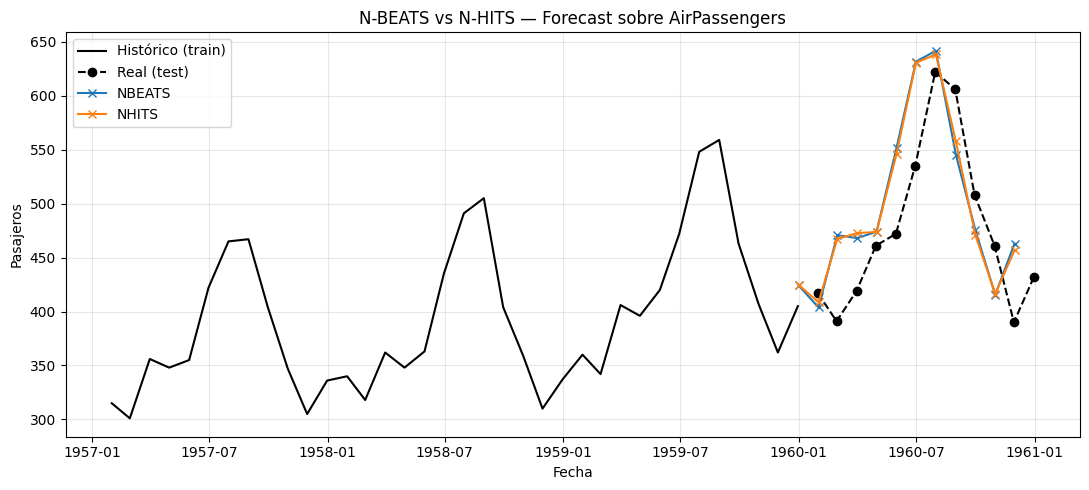

In [ ]:
graficar_comparacion(train, test, forecast, ["NBEATS", "NHITS"])